# Table of Contents

1. [Load Data](#load-data)
2. [Data Cleaning and Feature engineering](#data-cleaning-and-feature-engineering)
3. [Dimentionality Reduction](#dimentionality-reduction)
4. [KMeans Clustering](#kmeans-clustering)
5. [Result Analysis & Visualizations](#result-analysis--visualizations)

## Load Data

In [1]:
import pandas as pd
from pathlib import Path

csv_path = "../Clustering/clustering_Cleaned.csv"
df_full = pd.read_csv(csv_path)  # Keep full dataframe for later merging

# Drop specified columns
cols_to_drop = ['Debit_Amount_Total', 'Credit_Amount_Total', 'abm_transaction_count']
cols_to_drop = [col for col in cols_to_drop if col in df_full.columns]
if cols_to_drop:
    df_full = df_full.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
else:
    print("No specified columns found to drop")

# Filter for individual only
df = df_full[df_full['kyc_type'].str.lower() == 'individual'].copy()
print(f"Full dataset: {len(df_full)} rows")
print(f"Filtered to individual customers only: {len(df)} rows")

df.head()
df.isna().sum()

Dropped columns: ['Debit_Amount_Total', 'Credit_Amount_Total', 'abm_transaction_count']
Full dataset: 61410 rows
Filtered to individual customers only: 53099 rows


customer_id                                 0
kyc_type                                    0
province                                    0
city                                        0
industry_code                           53099
occupation_code                            87
sales_cents                             53099
account_age                              4025
birth_business_age                       3526
total_transaction_count                     0
transaction_count_ABM                       0
transaction_count_Card                      0
transaction_count_Cheque                    0
transaction_count_EFT                       0
transaction_count_EMT                       0
transaction_count_Western Union             0
transaction_count_Wire                      0
debit_transaction_count                   337
debit_transaction_amount                  337
credit_transaction_count                 1655
credit_transaction_amount                1655
average_debit_transaction_amount  

## Data Cleaning and Feature engineering

In [2]:
# Keep occupation_code for individual, drop industry_code
import numpy as np

# Drop industry_code (not needed for individual)
df = df.drop(columns=["industry_code"])

# Fill NA values in occupation_code with mode
if 'occupation_code' in df.columns:
    mode_value = df['occupation_code'].mode()
    if len(mode_value) > 0:
        df['occupation_code'] = df['occupation_code'].fillna(mode_value[0])
        print(f"Filled NA values in 'occupation_code' with mode: {mode_value[0]}")
    else:
        print("Warning: Could not find mode for 'occupation_code' (all values may be NA)")

# Convert occupation_code to categorical dtype (FAMD)
df["occupation_code"] = df["occupation_code"].astype("category")

print("occupation_code nunique:", df["occupation_code"].nunique())
print(df["occupation_code"].value_counts().head(10))

Filled NA values in 'occupation_code' with mode: OTHER
occupation_code nunique: 102
occupation_code
OTHER            10770
RETIRED          10243
STUDENT           6149
UNEMPLOYED        4952
SELF_EMPLOYED     4492
10019             1504
60010              709
14100              687
313                623
73300              618
Name: count, dtype: int64


In [3]:
# Replace occupation_code values that appear less than 50 times with "OTHER"
if 'occupation_code' in df.columns:
    # Count frequency of each occupation_code
    occupation_code_counts = df['occupation_code'].value_counts()
    
    # Find occupation_code values that appear less than 50 times (excluding NaN)
    rare_occupation_codes = occupation_code_counts[occupation_code_counts < 50].index.tolist()
    
    print(f"Found {len(rare_occupation_codes)} occupation_code values appearing less than 50 times")
    
    # Create mask for rows with rare occupation_code values
    rare_mask = df['occupation_code'].isin(rare_occupation_codes)
    print(f"Total rows to be changed: {rare_mask.sum()}")
    
    # Replace rare occupation_code values with "OTHER"
    df.loc[rare_mask, 'occupation_code'] = 'OTHER'
    
    # Convert back to category after replacement
    df['occupation_code'] = df['occupation_code'].astype('category')
    
    # Show updated distribution
    print(f"\nUpdated occupation_code distribution:")
    print(df['occupation_code'].value_counts().head(10))
else:
    print("Column 'occupation_code' not found in dataframe")

Found 14 occupation_code values appearing less than 50 times
Total rows to be changed: 490

Updated occupation_code distribution:
occupation_code
OTHER            11260
RETIRED          10243
STUDENT           6149
UNEMPLOYED        4952
SELF_EMPLOYED     4492
10019             1504
60010              709
14100              687
313                623
73300              618
Name: count, dtype: int64


In [4]:
# 2. account_age and birth_business_age: fill nulls with median
df['account_age'] = df['account_age'].fillna(df['account_age'].median())
df['birth_business_age'] = df['birth_business_age'].fillna(df['birth_business_age'].median())

# 3. Fill debit and credit nulls to 0
debit_credit_cols = [
    'debit_transaction_count',
    'debit_transaction_amount',
    'average_debit_transaction_amount',
    'credit_transaction_count',
    'credit_transaction_amount',
    'average_credit_transaction_amount'
]

for col in debit_credit_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Fill nulls in columns with prefix 'card_' or 'abm_' to 0
card_abm_cols = [col for col in df.columns if (col.startswith('card_') or col.startswith('abm_')) and col != 'abm_cash_to_non_cash_ratio']
for col in card_abm_cols:
    if col == 'card_top_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_second_mcc':
        df[col] = df[col].fillna('N/A')
    elif col == 'card_ecommerce_to_nonecommerce_ratio':
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(0)

In [5]:
# 5. Replace MCC codes in card_top_mcc that appear less than 100 times with "other"
if 'card_top_mcc' in df.columns:
    mcc_counts = df['card_top_mcc'].value_counts()
    
    # Find MCC codes that appear less than 100 times (excluding N/A and null)
    rare_mccs = mcc_counts[mcc_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_mccs:
        rare_mccs.remove('N/A')
    
    print(f"Found {len(rare_mccs)} MCC codes appearing less than 100 times")
    print(f"Total rows to be changed: {df['card_top_mcc'].isin(rare_mccs).sum()}")
    
    # Replace rare MCC codes with "other"
    df.loc[df['card_top_mcc'].isin(rare_mccs), 'card_top_mcc'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated card_top_mcc distribution:")
    print(df['card_top_mcc'].value_counts().head(10))
else:
    print("Column 'card_top_mcc' not found in dataframe")

Found 65 MCC codes appearing less than 100 times
Total rows to be changed: 1008

Updated card_top_mcc distribution:
card_top_mcc
5814     22206
5411     11382
N/A       7950
0         2329
5310      1677
5812      1412
other     1327
5541      1033
4816       609
4121       506
Name: count, dtype: int64


In [6]:
# 6. Replace cities that appear less than 100 times with "other"
if 'city' in df.columns:
    city_counts = df['city'].value_counts()
    
    # Find cities that appear less than 100 times (excluding N/A and null)
    rare_cities = city_counts[city_counts < 100].index.tolist()
    
    # Exclude 'N/A' from being replaced
    if 'N/A' in rare_cities:
        rare_cities.remove('N/A')
    
    print(f"Found {len(rare_cities)} cities appearing less than 100 times")
    print(f"Total rows to be changed: {df['city'].isin(rare_cities).sum()}")
    
    # Replace rare cities with "other"
    df.loc[df['city'].isin(rare_cities), 'city'] = 'other'
    
    # Show updated distribution
    print(f"\nUpdated city distribution:")
    print(df['city'].value_counts().head(10))
else:
    print("Column 'city' not found in dataframe")

Found 56 cities appearing less than 100 times
Total rows to be changed: 3542

Updated city distribution:
city
other          21168
TORONTO         3230
BRAMPTON        2046
CALGARY         1773
EDMONTON        1691
WINNIPEG        1291
SCARBOROUGH     1260
MISSISSAUGA     1200
SURREY          1094
VANCOUVER       1028
Name: count, dtype: int64


In [7]:
# 7. Remove customer_id, card_second_mcc, and sales_cents for individual
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
if 'card_second_mcc' in df.columns:
    df = df.drop(columns=['card_second_mcc'])
if 'sales_cents' in df.columns:
    df = df.drop(columns=['sales_cents'])

# Drop transaction count columns for Western Union and Wire
if 'transaction_count_Western Union' in df.columns:
    df = df.drop(columns=['transaction_count_Western Union'])
if 'transaction_count_Wire' in df.columns:
    df = df.drop(columns=['transaction_count_Wire'])

# Drop ABM non-cash count column
if 'abm_non_cash_count' in df.columns:
    df = df.drop(columns=['abm_non_cash_count'])

# Drop abm_cash_to_non_cash_ratio column
if 'abm_cash_to_non_cash_ratio' in df.columns:
    df = df.drop(columns=['abm_cash_to_non_cash_ratio'])
    print("Dropped 'abm_cash_to_non_cash_ratio' column")

# Note: sales_cents is dropped for individual analysis

# Handle the three new columns: Debit_Amount_Total, Credit_Amount_Total, Averagetime_between_alltransaction
# Rename Averagetime_between_alltransaction to Averagetime_between_transaction_day
if 'Averagetime_between_alltransaction' in df.columns:
    df = df.rename(columns={'Averagetime_between_alltransaction': 'Averagetime_between_transaction_day'})
    print("Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'")

# Fill Debit_Amount_Total and Credit_Amount_Total with 0
for col in ['Debit_Amount_Total', 'Credit_Amount_Total']:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"Filled null values in '{col}' with 0")
    else:
        print(f"Warning: Column '{col}' not found in dataframe")

# Fill Averagetime_between_transaction_day with median (not 0)
if 'Averagetime_between_transaction_day' in df.columns:
    median_value = df['Averagetime_between_transaction_day'].median()
    df['Averagetime_between_transaction_day'] = df['Averagetime_between_transaction_day'].fillna(median_value)
    print(f"Filled null values in 'Averagetime_between_transaction_day' with median: {median_value:.4f}")
else:
    print("Warning: Column 'Averagetime_between_transaction_day' not found in dataframe")

# Fill the three new time-based columns
# Fill std_time_between_transactions with median
if 'std_time_between_transactions' in df.columns:
    median_value = df['std_time_between_transactions'].median()
    df['std_time_between_transactions'] = df['std_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'std_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'std_time_between_transactions' not found in dataframe")

# Fill median_time_between_transactions with median
if 'median_time_between_transactions' in df.columns:
    median_value = df['median_time_between_transactions'].median()
    df['median_time_between_transactions'] = df['median_time_between_transactions'].fillna(median_value)
    print(f"Filled null values in 'median_time_between_transactions' with median: {median_value:.4f}")
else:
    print("Warning: Column 'median_time_between_transactions' not found in dataframe")

# pct_transactions_top10_busiest_days does not have NA values, so no filling needed
if 'pct_transactions_top10_busiest_days' in df.columns:
    na_count = df['pct_transactions_top10_busiest_days'].isna().sum()
    print(f"Column 'pct_transactions_top10_busiest_days' has {na_count} NA values (no filling needed)")
else:
    print("Warning: Column 'pct_transactions_top10_busiest_days' not found in dataframe")

Dropped 'abm_cash_to_non_cash_ratio' column
Renamed 'Averagetime_between_alltransaction' to 'Averagetime_between_transaction_day'
Filled null values in 'Averagetime_between_transaction_day' with median: 1.3292
Filled null values in 'std_time_between_transactions' with median: 1.3705
Filled null values in 'median_time_between_transactions' with median: 0.8467
Column 'pct_transactions_top10_busiest_days' has 0 NA values (no filling needed)


In [8]:
# Count number of categories for each categorical column after small category removal
print("CATEGORICAL COLUMNS - NUMBER OF CATEGORIES")
print("=" * 80)

# Identify categorical columns (object dtype and category dtype)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove kyc_type since it's constant
if 'kyc_type' in categorical_cols:
    categorical_cols.remove('kyc_type')
    df = df.drop(columns=['kyc_type'])

category_summary = []

for col in categorical_cols:
    n_unique = df[col].nunique()
    n_null = df[col].isna().sum()
    category_summary.append({
        'Column': col,
        'Number of Categories': n_unique,
        'Null Count': n_null,
        'Dtype': str(df[col].dtype)
    })

category_df = pd.DataFrame(category_summary)
category_df = category_df.sort_values('Number of Categories', ascending=False)

print(f"\nFound {len(categorical_cols)} categorical columns:\n")
print(category_df.to_string(index=False))

print("SUMMARY:")
print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Average categories per column: {category_df['Number of Categories'].mean():.1f}")
print(f"Max categories: {category_df['Number of Categories'].max()} ({category_df.loc[category_df['Number of Categories'].idxmax(), 'Column']})")
print(f"Min categories: {category_df['Number of Categories'].min()} ({category_df.loc[category_df['Number of Categories'].idxmin(), 'Column']})")

CATEGORICAL COLUMNS - NUMBER OF CATEGORIES

Found 4 categorical columns:

         Column  Number of Categories  Null Count    Dtype
occupation_code                    88           0 category
           city                    86           0   object
   card_top_mcc                    21           0   object
       province                    12           0   object
SUMMARY:
Total categorical columns: 4
Average categories per column: 51.8
Max categories: 88 (occupation_code)
Min categories: 12 (province)


In [9]:
print("DATA TYPE CLEANUP")
print("=" * 80)

# 2. Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns (will be preserved): {categorical_cols}")

# 3. Convert all non-categorical columns to float64
non_categorical_cols = [col for col in df.columns if col not in categorical_cols]
print(f"\nConverting {len(non_categorical_cols)} non-categorical columns to float64...")

conversion_summary = []
for col in non_categorical_cols:
    old_dtype = str(df[col].dtype)
    df[col] = df[col].astype('float64')
    new_dtype = str(df[col].dtype)
    conversion_summary.append({
        'Column': col,
        'Old Dtype': old_dtype,
        'New Dtype': new_dtype
    })

print(f"Converted {len(non_categorical_cols)} columns to float64")

# Show dtype summary
print("FINAL DATA TYPE SUMMARY:")
print(f"Total columns: {len(df.columns)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Float64 columns: {len(non_categorical_cols)}")

DATA TYPE CLEANUP

Categorical columns (will be preserved): ['province', 'city', 'occupation_code', 'card_top_mcc']

Converting 28 non-categorical columns to float64...
Converted 28 columns to float64
FINAL DATA TYPE SUMMARY:
Total columns: 32
Categorical columns: 4
Float64 columns: 28


## Dimentionality Reduction

In [10]:
import prince

df_famd = df.copy()
# Add customer_id back before saving to VersionB_BeforeFAMD.csv (preserving order, no sorting)
if 'customer_id' not in df_famd.columns:
    original_csv_path = "../Clustering/clustering_Cleaned.csv"
    df_original = pd.read_csv(original_csv_path)
    df_original = df_original[df_original['kyc_type'].str.lower() == 'individual'].copy()
    print(f"Full dataset: {len(df_original)} rows")
    print(f"Filtered to business customers only: {len(df_original)} rows")
    # Use index alignment to preserve order
    if len(df_original) == len(df_famd):
        df_original_reset = df_original.reset_index(drop=True)
        df_famd_reset = df_famd.reset_index(drop=True)
        df_famd['customer_id'] = df_original_reset['customer_id'].values
        print("customer_id restored from original dataset (order preserved)")
    else:
        raise ValueError(f"Row count mismatch! Original: {len(df_original)}, Current: {len(df_famd)}")

# Reorder columns to put customer_id first (preserving row order)
if 'customer_id' in df_famd.columns:
    cols = ['customer_id'] + [col for col in df_famd.columns if col != 'customer_id']
    df_famd = df_famd[cols]
before_famd = "../Clustering/VersionA_Individual_BeforeFAMD.csv"
df_famd.to_csv(before_famd, index=False)
print(f"Saved to {before_famd}")
# Remove customer_id after saving (preserving order)
if 'customer_id' in df_famd.columns:
    df_famd = df_famd.drop(columns=['customer_id'])
    print("customer_id removed after saving (order preserved)")

print(f"Fitting FAMD on full dataset with {len(df_famd)} rows...")

famd = prince.FAMD(
    n_components=10,   
    n_iter=3,
    copy=True,
    check_input=True,
    random_state=42,
    engine="sklearn",
    handle_unknown="error"
)

famd = famd.fit(df_famd)

famd.eigenvalues_summary

Full dataset: 53099 rows
Filtered to business customers only: 53099 rows
customer_id restored from original dataset (order preserved)
Saved to ../Clustering/VersionA_Individual_BeforeFAMD.csv
customer_id removed after saving (order preserved)
Fitting FAMD on full dataset with 53099 rows...


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,10.108,2.33%,2.33%
1,3.920,0.90%,3.23%
2,3.792,0.87%,4.11%
3,3.752,0.86%,4.97%
4,3.700,0.85%,5.82%
5,3.638,0.84%,6.66%
6,3.574,0.82%,7.48%
7,3.398,0.78%,8.27%
8,3.346,0.77%,9.04%


In [11]:
famd.column_contributions_.style.format('{:.2%}')

component,0,1,2,3,4,5,6,7,8,9
variable,,,,,,,,,,
account_age,0.01%,2.79%,0.05%,0.18%,0.18%,0.06%,0.08%,0.48%,1.15%,0.00%
birth_business_age,0.09%,3.10%,0.04%,0.16%,0.32%,0.10%,0.10%,0.53%,1.43%,0.01%
total_transaction_count,8.45%,0.00%,0.00%,0.00%,0.02%,0.01%,0.01%,0.02%,0.00%,0.00%
transaction_count_ABM,0.32%,0.11%,0.02%,0.00%,0.01%,0.00%,0.05%,0.16%,0.07%,0.22%
transaction_count_Card,8.61%,0.00%,0.01%,0.00%,0.01%,0.00%,0.01%,0.02%,0.00%,0.08%
transaction_count_Cheque,0.03%,0.20%,0.02%,0.00%,0.02%,0.02%,0.01%,0.04%,0.08%,0.03%
transaction_count_EFT,0.08%,0.01%,0.02%,0.02%,0.00%,0.01%,0.12%,0.01%,0.01%,0.22%
transaction_count_EMT,0.14%,0.12%,0.01%,0.01%,0.00%,0.01%,0.14%,0.03%,0.07%,0.30%
debit_transaction_count,8.85%,0.00%,0.00%,0.00%,0.02%,0.00%,0.00%,0.02%,0.00%,0.01%


In [12]:
# Row coordinates = FAMD component scores for each row
X_famd = famd.row_coordinates(df_famd)

print("FAMD scores shape:", X_famd.shape)
before_famd = "../Clustering/VersionA_Individual_AfterFAMD.csv"
X_famd.to_csv(before_famd, index=False)
X10 = X_famd.iloc[:, :10].to_numpy()

FAMD scores shape: (53099, 10)


## KMeans Clustering

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare dataset for clustering
X10_32 = np.asarray(X10, dtype=np.float32, order="C")
X = X10_32 

k_list = list(range(4, 12))
sil = []

for k in k_list:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    sil.append(s)
    print(f"k={k} silhouette={s:.4f}")

kmeans_results = pd.DataFrame({"k": k_list, "silhouette": sil})
print("\nKMeans results:")
print(kmeans_results)

k=4 silhouette=0.1912
k=5 silhouette=0.1989
k=6 silhouette=0.2144
k=7 silhouette=0.2348
k=8 silhouette=0.3011
k=9 silhouette=0.3316
k=10 silhouette=0.3588
k=11 silhouette=0.3382

KMeans results:
    k  silhouette
0   4    0.191181
1   5    0.198878
2   6    0.214445
3   7    0.234760
4   8    0.301095
5   9    0.331643
6  10    0.358776
7  11    0.338183


,k,inertia,silhouette
0,4,1.669458e+06,0.191181
1,5,1.491564e+06,0.198878
2,6,1.311142e+06,0.214445
3,7,1.145534e+06,0.234760
4,8,9.920115e+05,0.301095
5,9,8.267215e+05,0.331643
6,10,6.560227e+05,0.358776
7,11,6.041480e+05,0.338183


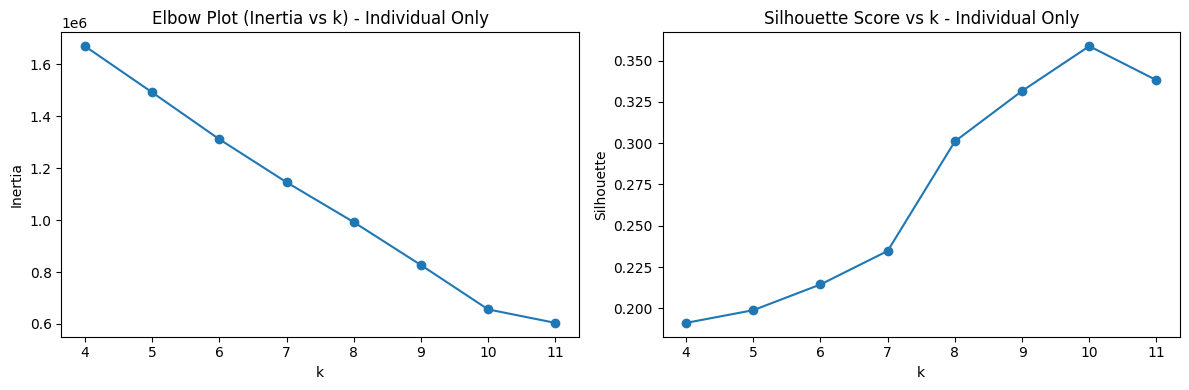

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Get silhouette series from existing results
if "kmeans_results" in globals():
    ks = kmeans_results["k"].tolist()
    sil_scores = kmeans_results["silhouette"].tolist()
else:
    ks = k_list
    sil_scores = sil

# Compute inertia for elbow
inertia = []
for k in ks:
    km = KMeans(n_clusters=int(k), n_init="auto", random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# combine into one table
eval_df = pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil_scores})
display(eval_df)

# Plot: Elbow + Silhouette (two panels)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ks, inertia, marker="o")
ax[0].set_title("Elbow Plot (Inertia vs k) - Individual Only")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(ks, sil_scores, marker="o")
ax[1].set_title("Silhouette Score vs k - Individual Only")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import KMeans

# Fit KMeans 
k_final = 9
km_final = KMeans(
    n_clusters=k_final,
    n_init="auto",
    random_state=42
)

df["cluster"] = km_final.fit_predict(X)

# Add prefix to cluster labels
df["cluster"] = "individual_" + df["cluster"].astype(str)

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
individual_0    11501
individual_1     4708
individual_2     4402
individual_3    14730
individual_4      601
individual_5      362
individual_6     1259
individual_7    14134
individual_8     1402
Name: count, dtype: int64


In [16]:
# Restore customer_id from df_full for merging
# Match individual customers from df_full using the filtered indices
individual_mask = df_full['kyc_type'].str.lower() == 'individual'
df_full_individual = df_full[individual_mask].copy().reset_index(drop=True)
df_with_id = df.reset_index(drop=True).copy()
df_with_id['customer_id'] = df_full_individual['customer_id'].values

# Save cluster results to separate individual CSV (for reference)
output_path_individual = "../Clustering/Kmeans_Individual.csv"
df_with_id.to_csv(output_path_individual, index=False)
print(f"Individual cluster results saved to {output_path_individual}")
print(f"Total rows saved: {len(df_with_id)}")
print(f"Columns saved: {len(df_with_id.columns)}")

# Save to combined Kmeans_Seperate.csv
output_path_separate = "../Clustering/Kmeans_Seperate.csv"

# Create dataframe with customer_id and cluster label
individual_clusters = df_with_id[['customer_id', 'cluster']].copy()

# Check if Kmeans_Seperate.csv exists
if Path(output_path_separate).exists():
    # Read existing file and merge individual cluster labels
    df_separate = pd.read_csv(output_path_separate)
    print(f"\nFound existing {output_path_separate} with {len(df_separate)} rows")
    
    # Merge individual cluster labels
    if 'cluster' in df_separate.columns:
        # Update existing cluster column for individual customers
        df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left', suffixes=('', '_new'))
        df_separate['cluster'] = df_separate['cluster_new'].fillna(df_separate['cluster'])
        df_separate = df_separate.drop(columns=['cluster_new'])
    else:
        # Add cluster column
        df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left')
else:
    # Create new file from full dataframe with individual cluster labels
    df_separate = df_full[['customer_id']].copy()
    df_separate = df_separate.merge(individual_clusters, on='customer_id', how='left')
    print(f"\nCreating new {output_path_separate}")

# Save to Kmeans_Seperate.csv
df_separate.to_csv(output_path_separate, index=False)
print(f"  Total rows: {len(df_separate)}")
print(f"  Customers without cluster labels: {df_separate['cluster'].isna().sum()}")

Individual cluster results saved to ../Clustering/Kmeans_Individual.csv
Total rows saved: 53099
Columns saved: 34

Found existing ../Clustering/Kmeans_Seperate.csv with 61410 rows
  Total rows: 61410
  Customers without cluster labels: 0


## Result Analysis & Visualizations

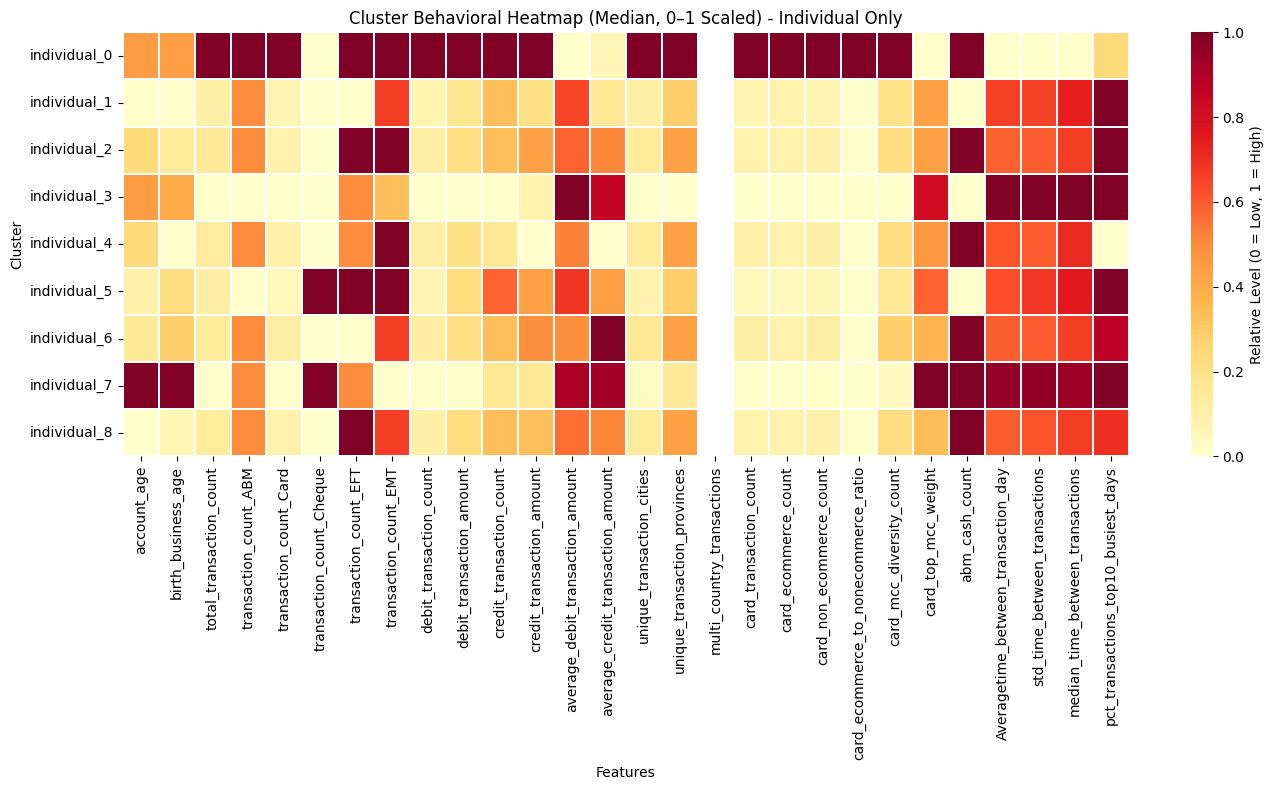

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include="number").columns.drop("cluster", errors="ignore")

# Cluster medians
cluster_medians = df.groupby("cluster")[num_cols].median()

# Min–max scale per feature (column-wise)
cluster_medians_01 = (
    cluster_medians - cluster_medians.min()
) / (cluster_medians.max() - cluster_medians.min())

plt.figure(figsize=(14, 8))
sns.heatmap(
    cluster_medians_01,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"label": "Relative Level (0 = Low, 1 = High)"}
)

plt.title("Cluster Behavioral Heatmap (Median, 0–1 Scaled) - Individual Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [20]:
# Categorize features by score ranges for each cluster
print("=" * 80)
print("FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)")
print("=" * 80)
print()

for cluster in sorted(cluster_medians_01.index):
    cluster_scores = cluster_medians_01.loc[cluster]
    
    # High scores: 0.65 to 1.0
    high_features = cluster_scores[(cluster_scores >= 0.65) & (cluster_scores <= 1.0)].sort_values(ascending=False)
    
    # Moderate scores: 0.35 to 0.65
    moderate_features = cluster_scores[(cluster_scores >= 0.35) & (cluster_scores < 0.65)].sort_values(ascending=False)
    
    print(f"{cluster}:")
    print(f"  High (0.65-1.0): {list(high_features.index)}")
    print(f"  Moderate (0.35-0.65): {list(moderate_features.index)}")
    print()

FEATURE CATEGORIZATION BY CLUSTER (Numerical Heatmap Scores)

individual_0:
  High (0.65-1.0): ['total_transaction_count', 'unique_transaction_cities', 'card_mcc_diversity_count', 'card_ecommerce_to_nonecommerce_ratio', 'card_non_ecommerce_count', 'card_ecommerce_count', 'card_transaction_count', 'unique_transaction_provinces', 'credit_transaction_amount', 'transaction_count_ABM', 'credit_transaction_count', 'debit_transaction_amount', 'debit_transaction_count', 'transaction_count_EMT', 'transaction_count_EFT', 'transaction_count_Card', 'abm_cash_count']
  Moderate (0.35-0.65): ['account_age', 'birth_business_age']

individual_1:
  High (0.65-1.0): ['pct_transactions_top10_busiest_days', 'median_time_between_transactions', 'transaction_count_EMT', 'Averagetime_between_transaction_day', 'std_time_between_transactions']
  Moderate (0.35-0.65): ['average_debit_transaction_amount', 'transaction_count_ABM', 'card_top_mcc_weight']

individual_2:
  High (0.65-1.0): ['transaction_count_EFT', '

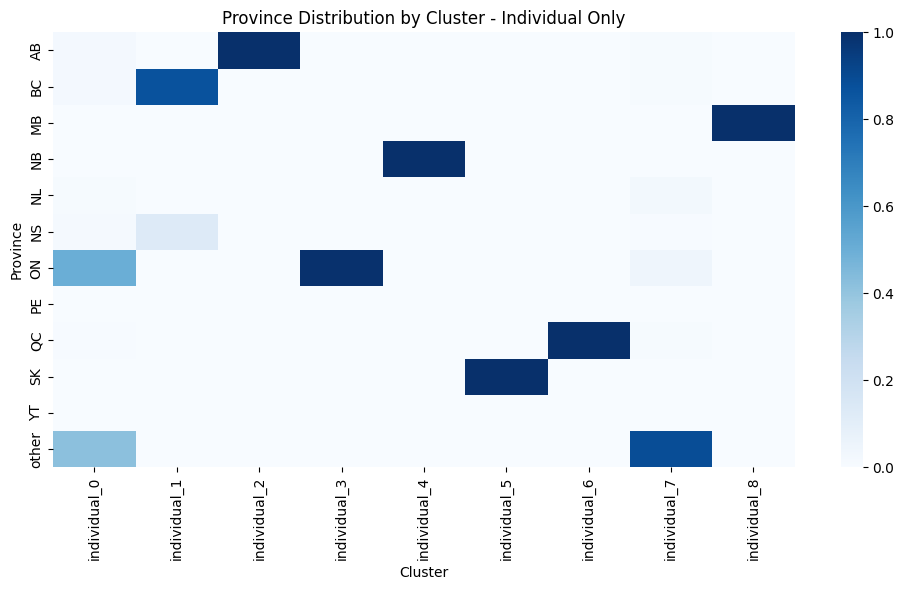

In [18]:
province_dist = pd.crosstab(
    df["province"],
    df["cluster"],
    normalize="columns"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    province_dist,
    cmap="Blues"
)
plt.title("Province Distribution by Cluster - Individual Only")
plt.xlabel("Cluster")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

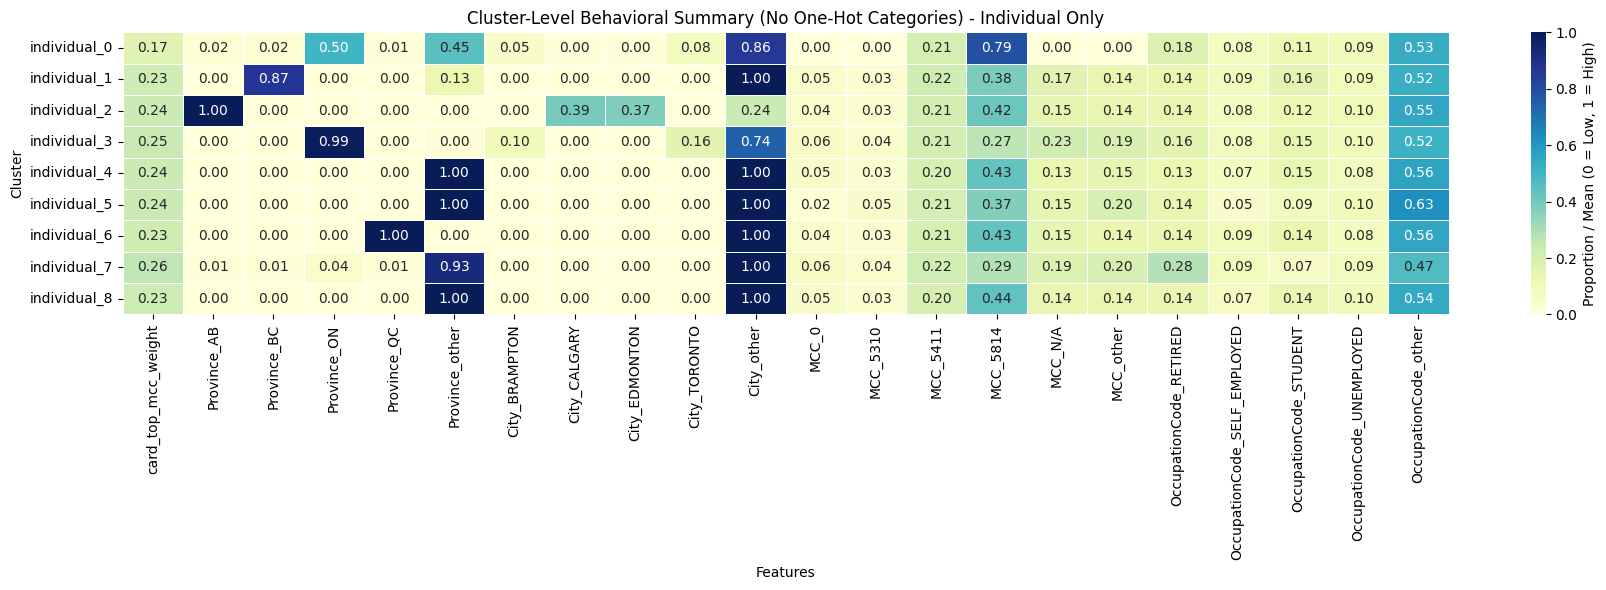

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Function: categorical proportions
def categorical_cluster_proportions(df, cluster_col, cat_col, top_n=5):
    """
    Rows = clusters
    Columns = top-N categories (+ other)
    Values = proportion within cluster
    """
    # Convert to string if categorical to avoid type errors
    col_series = df[cat_col].astype(str) if df[cat_col].dtype.name == 'category' else df[cat_col]
    
    # Normalize all "other" variations to lowercase "other" first
    # Preserve original case for non-other values
    other_mask = col_series.str.lower() == 'other'
    col_series_normalized = col_series.copy()
    col_series_normalized[other_mask] = 'other'
    
    # Get top_n values from normalized series
    top_vals = col_series_normalized.value_counts().head(top_n).index.tolist()
    
    # Since we've normalized all "other" to lowercase, we can safely collapse to "other"
    collapsed = col_series_normalized.where(col_series_normalized.isin(top_vals), "other")

    return pd.crosstab(
        df[cluster_col],
        collapsed,
        normalize="index"
    )

# Build heatmap dataframe
heatmap_df = pd.DataFrame(
    index=sorted(df["cluster"].unique())
)

# Numeric dominance / indicator-style features
heatmap_df["card_top_mcc_weight"] = (
    df.groupby("cluster")["card_top_mcc_weight"].mean()
)


# Categorical summaries (NO indicators)

# Province (top 5)
prov_prop = categorical_cluster_proportions(df, "cluster", "province", top_n=5)
prov_prop.columns = [f"Province_{c}" for c in prov_prop.columns]
heatmap_df = heatmap_df.join(prov_prop)

# City (top 5)
city_prop = categorical_cluster_proportions(df, "cluster", "city", top_n=5)
city_prop.columns = [f"City_{c}" for c in city_prop.columns]
heatmap_df = heatmap_df.join(city_prop)

# Top MCC (top 5)
mcc_prop = categorical_cluster_proportions(df, "cluster", "card_top_mcc", top_n=5)
mcc_prop.columns = [f"MCC_{c}" for c in mcc_prop.columns]
heatmap_df = heatmap_df.join(mcc_prop)

# Occupation code (top 5)
occupation_code_prop = categorical_cluster_proportions(df, "cluster", "occupation_code", top_n=5)
occupation_code_prop.columns = [f"OccupationCode_{c}" for c in occupation_code_prop.columns]
heatmap_df = heatmap_df.join(occupation_code_prop)

# Plot heatmap 
plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Proportion / Mean (0 = Low, 1 = High)"}
)

plt.title("Cluster-Level Behavioral Summary (No One-Hot Categories) - Individual Only")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()